In [1]:
import selenium
from selenium import webdriver

In [2]:
driver=webdriver.Chrome()

In [3]:
from selenium.webdriver.chrome.options import Options
options= Options()

In [4]:
options.add_argument("--start-maximized")

In [5]:
driver=webdriver.Chrome(options=options)

In [6]:
url='https://www.rottentomatoes.com/'
driver.get(url)

In [7]:
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys

In [8]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

button = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.ID, "onetrust-accept-btn-handler"))
)
button.click()

In [9]:
search_box = driver.find_element(By.XPATH,'//*[@id="header-main"]/search-results-nav/search-results-controls/input')

In [10]:
search_box.send_keys(Keys.RETURN)

In [11]:
search_box.send_keys("Ai")

In [21]:
search_box.send_keys(Keys.RETURN)

In [22]:
import numpy as np
import pandas as pd
import requests

### MOVIE NAME

In [23]:
    hosts = driver.find_elements(By.TAG_NAME, "search-page-media-row")

In [24]:
movie_name = []
rows = driver.find_elements(By.TAG_NAME, "search-page-media-row")
print(len(rows))

for row in rows:
    try:
        text = row.find_element(By.CSS_SELECTOR, '[slot="title"]').text.strip()
        movie_name.append(text if text else np.nan)
    except:
        movie_name.append(np.nan)

print(movie_name)

20
['The AI Doc: Or How I Became an Apocaloptimist', 'A.I.: Artificial Intelligence', 'The Last Airbender', 'Air', 'Airplane!', 'Con Air', 'Up in the Air', 'The Greek Aisle', 'Air Force One', 'Aileen: Queen of the Serial Killers', 'AI Confidential with Hannah Fry', 'Eric en Plein Air', 'Inside Melbourne Airport', 'Cocaine Air: Smugglers at 30,000 Ft.', 'The Banished Court Magician Aims to Become the Strongest', 'Toronto Airport Uncovered', "Live Aid: When Rock 'n' Roll Took on the World", 'Aitana: Metamorphosis', 'Masters of the Air', 'Avatar: The Last Airbender']


In [55]:
year=[]
hosts = driver.find_elements(By.TAG_NAME, "search-page-media-row")
for host in hosts:
    try:
        shadow = driver.execute_script("return arguments[0].shadowRoot", host)
        y_text = shadow.find_element(By.CSS_SELECTOR, '[data-qa="info-year"]').text
        year.append(y_text if y_text else np.nan)
    except Exception:
        year.append(np.nan)
year

['(2026)',
 '(2001)',
 '(2010)',
 '(2023)',
 '(1980)',
 '(1997)',
 '(2009)',
 '(2026)',
 '(1997)',
 '(2025)',
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]

In [26]:
critics_score = []

for host in hosts:
    try:
        shadow = driver.execute_script("return arguments[0].shadowRoot", host)
        el = shadow.find_element(By.CLASS_NAME, "critics-score")
        critics_score.append(el.text)
    except:
        critics_score.append(np.nan)

critics_score

['88%',
 '76%',
 '5%',
 '93%',
 '97%',
 '59%',
 '90%',
 '',
 '78%',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '']

In [27]:
image_link = []

for host in hosts:
    try:
        img = host.find_element(By.CSS_SELECTOR, '[slot="thumbnail"] img')
        image_link.append(img.get_attribute("src"))
    except:
        image_link.append(np.nan)

image_link

['https://resizing.flixster.com/21aI6JFf2HWPPMEfRcVVHWGHRZM=/fit-in/80x126/v2/https://resizing.flixster.com/BhE49z6xOkLRFjBWBNAl_c5bV_o=/ems.cHJkLWVtcy1hc3NldHMvbW92aWVzLzVjZWRmM2Q5LThmMWQtNGFlYi1iYWMxLTZlYTMwZTAzNjdjZi5qcGc=',
 'https://resizing.flixster.com/zVbk-YfRQExl9w0Tq_Kz_q3GCsY=/fit-in/80x126/v2/https://resizing.flixster.com/-XZAfHZM39UwaGJIFWKAE8fS0ak=/v3/t/assets/p27945_p_v8_bb.jpg',
 'https://resizing.flixster.com/CyBiJChmgYjHT8Vz6Z6hfVgImnk=/fit-in/80x126/v2/https://resizing.flixster.com/-XZAfHZM39UwaGJIFWKAE8fS0ak=/v3/t/assets/p3597018_p_v10_aq.jpg',
 'https://resizing.flixster.com/VKVnaaXGnVsRKwXyuUg07HyJO4s=/fit-in/80x126/v2/https://resizing.flixster.com/YCmO8jyzF8PEJ5djT_x4TiRAw7Y=/ems.cHJkLWVtcy1hc3NldHMvbW92aWVzLzg0MjcwZGUyLTE4NzctNDgyMi05ZmI0LWM4OWJkZjgxMDMyMi5qcGc=',
 'https://resizing.flixster.com/f9yG6nevZkd8vGRm6gEophXY2Tc=/fit-in/80x126/v2/https://resizing.flixster.com/-XZAfHZM39UwaGJIFWKAE8fS0ak=/v3/t/assets/p1671_p_v11_aa.jpg',
 'https://resizing.flixster.com

In [28]:
import time

cast = []
for host in hosts:
    try:
        driver.execute_script("arguments[0].scrollIntoView({block:'center'});", host)
        time.sleep(0.3)  
        shadow = driver.execute_script("return arguments[0].shadowRoot", host)
        el = shadow.find_element(By.CSS_SELECTOR, '[data-qa="info-cast"]')
        cast.append(el.text)
    except:
        cast.append(np.nan)

cast

['',
 "Haley Joel Osment, Jude Law, Frances O'Connor",
 'Noah Ringer, Dev Patel, Nicola Peltz Beckham',
 'Matt Damon, Ben Affleck, Jason Bateman',
 'Robert Hays, Julie Hagerty, Peter Graves',
 'Nicolas Cage, John Cusack, John Malkovich',
 'George Clooney, Vera Farmiga, Anna Kendrick',
 'Nikki Deloach, Apostolis Totsikas',
 'Harrison Ford, Gary Oldman, Glenn Close',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '']

In [31]:
next_btn = driver.find_elements(By.CSS_SELECTOR, '[data-qa="paging-btn-next"]')[0]

In [32]:
try:
    next_btn = driver.find_elements(By.CSS_SELECTOR, '[data-qa="paging-btn-next"]')[0]
    driver.execute_script("arguments[0].scrollIntoView({block:'center'});", next_btn)
    time.sleep(0.3)
    driver.execute_script("arguments[0].click();", next_btn)
    time.sleep(1.5)
    page_num += 1
except Exception as e:
    print("Could not click NEXT:", e)
 

Could not click NEXT: name 'page_num' is not defined


In [33]:

import time
import numpy as np
from selenium.webdriver.common.by import By

title = []
year = []
critics_score = []
cast = []
image_link = []

TARGET = 1500
page_num = 1

while len(title) < TARGET:

    hosts = driver.find_elements(By.TAG_NAME, "search-page-media-row")

    for host in hosts:
        # --- title (light DOM, scoped to this host) ---
        try:
            t = host.find_element(By.CSS_SELECTOR, '[slot="title"]').text.strip()
            title.append(t if t else np.nan)
        except Exception:
            title.append(np.nan)

        # --- image (light DOM, scoped to this host) ---
        try:
            img = host.find_element(By.CSS_SELECTOR, '[slot="thumbnail"] img')
            image_link.append(img.get_attribute("src"))
        except Exception:
            image_link.append(np.nan)

        # --- year / score / cast live in the shadow DOM of this host ---
        try:
            shadow = driver.execute_script("return arguments[0].shadowRoot", host)
        except Exception:
            shadow = None

        try:
            y_text = shadow.find_element(By.CSS_SELECTOR, '[data-qa="info-year"]').text
            year.append(y_text if y_text else np.nan)
        except Exception:
            year.append(np.nan)

        try:
            s_text = shadow.find_element(By.CLASS_NAME, "critics-score").text
            critics_score.append(s_text if s_text else np.nan)
        except Exception:
            critics_score.append(np.nan)

        try:
            c_text = shadow.find_element(By.CSS_SELECTOR, '[data-qa="info-cast"]').text
            cast.append(c_text if c_text else np.nan)
        except Exception:
            cast.append(np.nan)

    print(f'Page {page_num} scraped, total records: {len(title)}')

    if len(title) >= TARGET:
        break

    try:
        next_btn = driver.find_elements(By.CSS_SELECTOR, '[data-qa="paging-btn-next"]')[0]
        driver.execute_script("arguments[0].scrollIntoView({block:'center'});", next_btn)
        time.sleep(0.3)
        driver.execute_script("arguments[0].click();", next_btn)
        time.sleep(1.5)
        page_num += 1
    except Exception as e:
        print("Could not click NEXT:", e)
        break


Page 1 scraped, total records: 20
Page 2 scraped, total records: 40
Page 3 scraped, total records: 60
Page 4 scraped, total records: 80
Page 5 scraped, total records: 100
Page 6 scraped, total records: 120
Page 7 scraped, total records: 140
Page 8 scraped, total records: 160
Page 9 scraped, total records: 180
Page 10 scraped, total records: 200
Page 11 scraped, total records: 220
Page 12 scraped, total records: 240
Page 13 scraped, total records: 260
Page 14 scraped, total records: 280
Page 15 scraped, total records: 300
Page 16 scraped, total records: 320
Page 17 scraped, total records: 340
Page 18 scraped, total records: 360
Page 19 scraped, total records: 380
Page 20 scraped, total records: 400
Page 21 scraped, total records: 420
Page 22 scraped, total records: 440
Page 23 scraped, total records: 460
Page 24 scraped, total records: 480
Page 25 scraped, total records: 500
Page 26 scraped, total records: 520
Page 27 scraped, total records: 540
Page 28 scraped, total records: 560
Page 

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df.info()

null_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print("--- Missing Values Summary ---")
print(null_summary)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          1500 non-null   object
 1   Year           750 non-null    object
 2   Critics_Score  600 non-null    object
 3   Cast           600 non-null    object
 4   Image_Link     1500 non-null   object
dtypes: object(5)
memory usage: 58.7+ KB
--- Missing Values Summary ---
               Missing Values  Percentage (%)
Title                       0             0.0
Year                      750            50.0
Critics_Score             900            60.0
Cast                      900            60.0
Image_Link                  0             0.0


In [59]:
import pandas as pd

print(f"Titles: {len(title)}, Years: {len(year)}, Scores: {len(critics_score)}, Cast: {len(cast)}, Images: {len(image_link)}")

min_len = min(len(title), len(year), len(critics_score), len(cast), len(image_link))

data = {
    'Title': title[:min_len],
    'Year': year[:min_len],
    'Critics_Score': critics_score[:min_len],
    'Cast': cast[:min_len],
    'Image_Link': image_link[:min_len]
}

df = pd.DataFrame(data)
df.to_csv('rotten_tomatoes_movies.csv', index=False)

print(f"DataFrame saved successfully with {len(df)} rows!")
df.head(50)


Titles: 1500, Years: 20, Scores: 1500, Cast: 1500, Images: 1500
DataFrame saved successfully with 20 rows!


,Title,Year,Critics_Score,Cast,Image_Link
0,The AI Doc: Or How I Became an Apocaloptimist,(2026),88%,NaN,https://resizing.flixster.com/21aI6JFf2HWPPMEf...
1,A.I.: Artificial Intelligence,(2001),76%,"Haley Joel Osment, Jude Law, Frances O'Connor",https://resizing.flixster.com/zVbk-YfRQExl9w0T...
2,The Last Airbender,(2010),5%,"Noah Ringer, Dev Patel, Nicola Peltz Beckham",https://resizing.flixster.com/CyBiJChmgYjHT8Vz...
3,Air,(2023),93%,"Matt Damon, Ben Affleck, Jason Bateman",https://resizing.flixster.com/VKVnaaXGnVsRKwXy...
4,Airplane!,(1980),97%,"Robert Hays, Julie Hagerty, Peter Graves",https://resizing.flixster.com/f9yG6nevZkd8vGRm...
5,Con Air,(1997),59%,"Nicolas Cage, John Cusack, John Malkovich",https://resizing.flixster.com/KyD9kkHyDFTAKIGl...
6,Up in the Air,(2009),90%,"George Clooney, Vera Farmiga, Anna Kendrick",https://resizing.flixster.com/I4FIeWc1tTnNOBi1...
7,The Greek Aisle,(2026),NaN,"Nikki Deloach, Apostolis Totsikas",https://resizing.flixster.com/DMuzDAeQ4Q9YVD4V...
8,Air Force One,(1997),78%,"Harrison Ford, Gary Oldman, Glenn Close",https://resizing.flixster.com/Mhbd4u5OA2Qufp6m...
9,Aileen: Queen of the Serial Killers,(2025),NaN,NaN,https://resizing.flixster.com/Q2mT3_QL8MlWq1vS...


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          20 non-null     object
 1   Year           10 non-null     object
 2   Critics_Score  8 non-null      object
 3   Cast           8 non-null      object
 4   Image_Link     20 non-null     object
dtypes: object(5)
memory usage: 932.0+ bytes


In [41]:

df_clean = df.copy()
df_clean['Cast'] = df_clean['Cast'].fillna("Unknown")

print(f"Dataset shape: {df_clean.shape}")
df_clean.info()


Dataset shape: (1500, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          1500 non-null   object
 1   Year           750 non-null    object
 2   Critics_Score  600 non-null    object
 3   Cast           1500 non-null   object
 4   Image_Link     1500 non-null   object
dtypes: object(5)
memory usage: 58.7+ KB


In [61]:

df_clean['Score_Numeric'] = pd.to_numeric(
    df_clean['Critics_Score'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
)

n_missing_score = df_clean['Score_Numeric'].isna().sum()
score_median = df_clean['Score_Numeric'].median()
print(f"Critics_Score missing: {n_missing_score} rows -> filled with median {score_median}%")

df_clean['Score_Numeric'] = df_clean['Score_Numeric'].fillna(score_median)
df_clean['Critics_Score'] = df_clean['Score_Numeric'].round(1).astype(str) + '%'


Critics_Score missing: 0 rows -> filled with median 83.0%


In [64]:
df_clean.head(5)

,Title,Year,Critics_Score,Cast,Image_Link,Score_Numeric,Score_Category
0,The AI Doc: Or How I Became an Apocaloptimist,2026,88.0%,Unknown,https://resizing.flixster.com/21aI6JFf2HWPPMEf...,88.0,HIT (>=75%)
1,A.I.: Artificial Intelligence,2001,76.0%,"Haley Joel Osment, Jude Law, Frances O'Connor",https://resizing.flixster.com/zVbk-YfRQExl9w0T...,76.0,HIT (>=75%)
2,The Last Airbender,2010,5.0%,"Noah Ringer, Dev Patel, Nicola Peltz Beckham",https://resizing.flixster.com/CyBiJChmgYjHT8Vz...,5.0,Below Average (<60%)
3,Air,2023,93.0%,"Matt Damon, Ben Affleck, Jason Bateman",https://resizing.flixster.com/VKVnaaXGnVsRKwXy...,93.0,HIT (>=75%)
4,Airplane!,1980,97.0%,"Robert Hays, Julie Hagerty, Peter Graves",https://resizing.flixster.com/f9yG6nevZkd8vGRm...,97.0,HIT (>=75%)


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


In [65]:
df_clean.info()
df_clean.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Title           1500 non-null   object 
 1   Year            1500 non-null   int64  
 2   Critics_Score   1500 non-null   object 
 3   Cast            1500 non-null   object 
 4   Image_Link      1500 non-null   object 
 5   Score_Numeric   1500 non-null   float64
 6   Score_Category  1500 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 82.2+ KB


,Title,Year,Critics_Score,Cast,Image_Link,Score_Numeric,Score_Category
0,The AI Doc: Or How I Became an Apocaloptimist,2026,88.0%,Unknown,https://resizing.flixster.com/21aI6JFf2HWPPMEf...,88.0,HIT (>=75%)
1,A.I.: Artificial Intelligence,2001,76.0%,"Haley Joel Osment, Jude Law, Frances O'Connor",https://resizing.flixster.com/zVbk-YfRQExl9w0T...,76.0,HIT (>=75%)
2,The Last Airbender,2010,5.0%,"Noah Ringer, Dev Patel, Nicola Peltz Beckham",https://resizing.flixster.com/CyBiJChmgYjHT8Vz...,5.0,Below Average (<60%)
3,Air,2023,93.0%,"Matt Damon, Ben Affleck, Jason Bateman",https://resizing.flixster.com/VKVnaaXGnVsRKwXy...,93.0,HIT (>=75%)
4,Airplane!,1980,97.0%,"Robert Hays, Julie Hagerty, Peter Graves",https://resizing.flixster.com/f9yG6nevZkd8vGRm...,97.0,HIT (>=75%)
5,Con Air,1997,59.0%,"Nicolas Cage, John Cusack, John Malkovich",https://resizing.flixster.com/KyD9kkHyDFTAKIGl...,59.0,Below Average (<60%)
6,Up in the Air,2009,90.0%,"George Clooney, Vera Farmiga, Anna Kendrick",https://resizing.flixster.com/I4FIeWc1tTnNOBi1...,90.0,HIT (>=75%)
7,The Greek Aisle,2026,83.0%,"Nikki Deloach, Apostolis Totsikas",https://resizing.flixster.com/DMuzDAeQ4Q9YVD4V...,83.0,HIT (>=75%)
8,Air Force One,1997,78.0%,"Harrison Ford, Gary Oldman, Glenn Close",https://resizing.flixster.com/Mhbd4u5OA2Qufp6m...,78.0,HIT (>=75%)
9,Aileen: Queen of the Serial Killers,2025,83.0%,Unknown,https://resizing.flixster.com/Q2mT3_QL8MlWq1vS...,83.0,HIT (>=75%)


### 1. Univariate Analysis

In [63]:
def categorize_score(score):
    if pd.isna(score):
        return 'Not Rated'
    elif score >= 75:
        return 'HIT (>=75%)'
    elif score >= 60:
        return 'Average (60-74%)'
    else:
        return 'Below Average (<60%)'

df_clean['Score_Category'] = df_clean['Score_Numeric'].apply(categorize_score)

counts = df_clean['Score_Category'].value_counts()
explode_values = tuple([0.05] * len(counts))

print("Score Categories Created Successfully!")
print(counts)


Score Categories Created Successfully!
Score_Category
HIT (>=75%)             1350
Below Average (<60%)     150
Name: count, dtype: int64


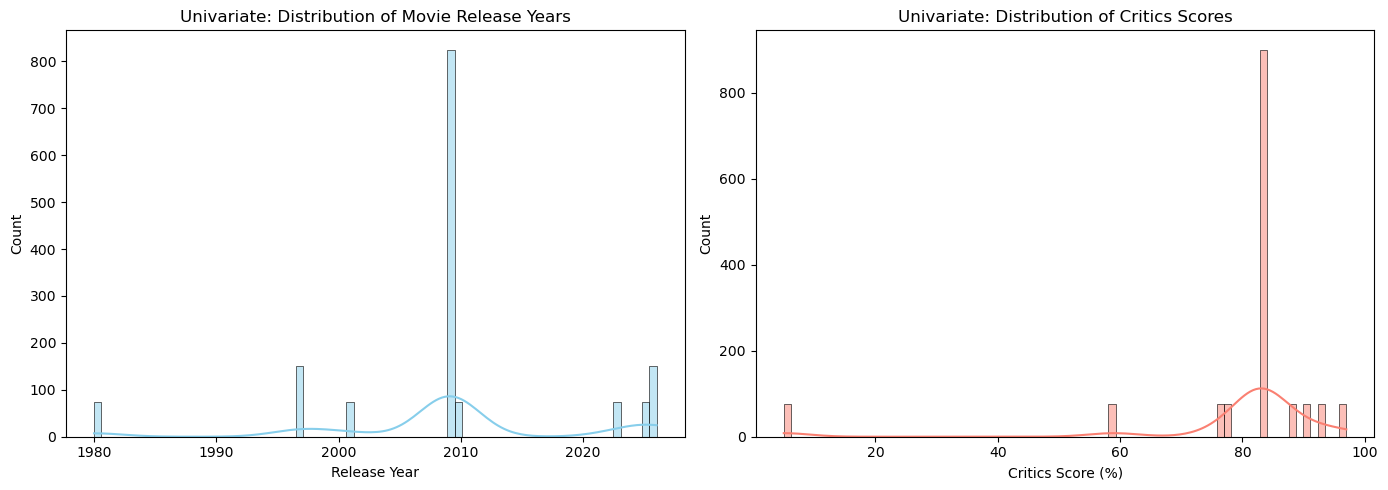

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Release Year distribution
sns.histplot(df_clean['Year'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Univariate: Distribution of Movie Release Years')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Count')

# Graph 2: Critics Score distribution
sns.histplot(df_clean['Score_Numeric'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Univariate: Distribution of Critics Scores')
axes[1].set_xlabel('Critics Score (%)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

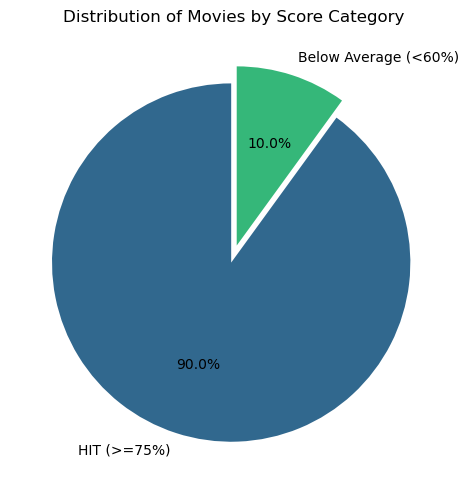

In [81]:
plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    explode=explode_values,
    colors=sns.color_palette('viridis', len(counts)),
    startangle=90
)
plt.title('Distribution of Movies by Score Category')
plt.tight_layout()
plt.show()

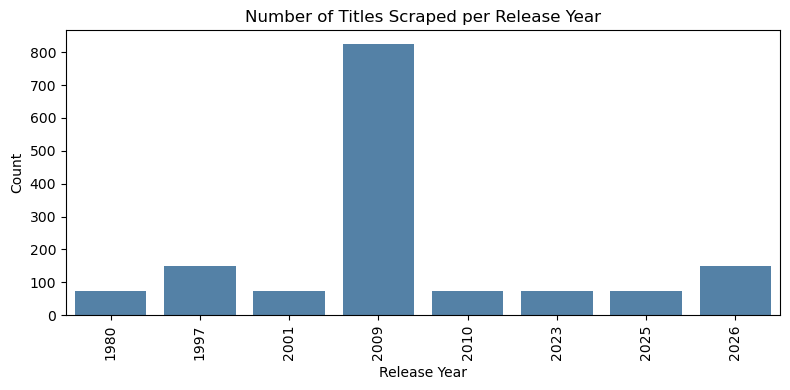

In [83]:
plt.figure(figsize=(8, 4))
year_order = sorted(df_clean['Year'].dropna().unique())
sns.countplot(data=df_clean, x='Year', order=year_order, color='steelblue')
plt.title('Number of Titles Scraped per Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Bivariate Analysis

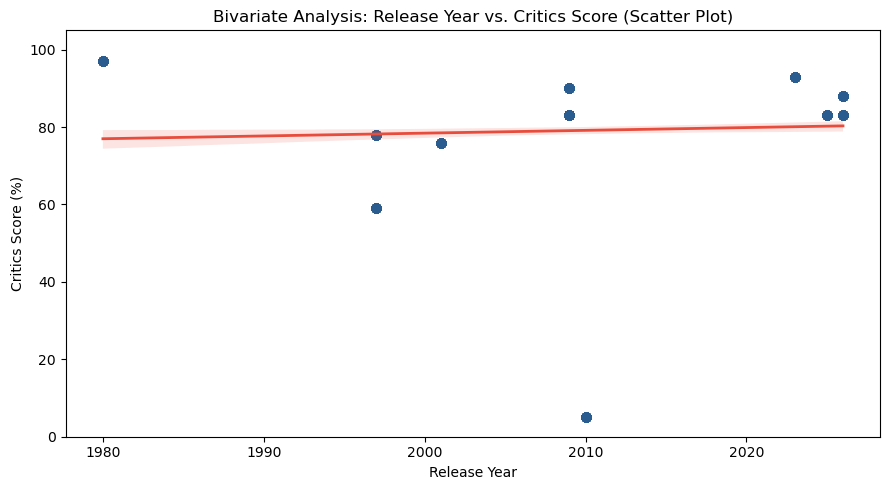

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_clean,
    x='Year',
    y='Score_Numeric',
    scatter_kws={'alpha': 0.6, 'color': '#2b5c8f', 's': 40},
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)

plt.title('Bivariate Analysis: Release Year vs. Critics Score (Scatter Plot)')
plt.xlabel('Release Year')
plt.ylabel('Critics Score (%)')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()


In [74]:
df_actors = df_clean.assign(
    Actor=df_clean['Cast'].astype(str).str.split(',').str[:3]  # top 3 credited actors
).explode('Actor')
df_actors['Actor'] = df_actors['Actor'].str.strip()

df_actors = df_actors[~df_actors['Actor'].isin(['', 'nan', 'None', 'Unknown'])].dropna(
    subset=['Score_Numeric']
)
actor_stats = (
    df_actors.groupby('Actor')['Score_Numeric']
    .agg(avg_score='mean', num_titles='count')
    .reset_index()
)
MIN_TITLES = 3
top_actors = (
    actor_stats[actor_stats['num_titles'] >= MIN_TITLES]
    .nlargest(10, 'avg_score')
)

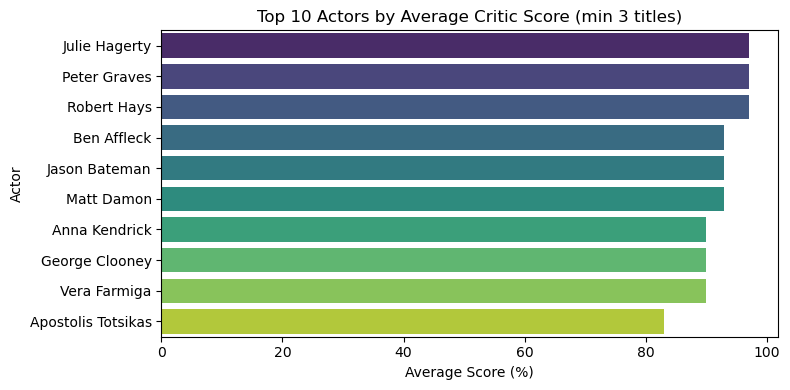

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.barplot(data=top_actors, x='avg_score', y='Actor', hue='Actor', palette='viridis', legend=False)
plt.title(f'Top 10 Actors by Average Critic Score (min {MIN_TITLES} titles)')
plt.xlabel('Average Score (%)')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()

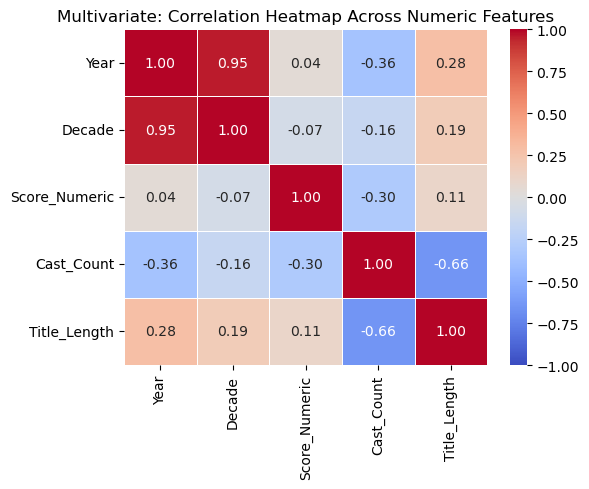

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
df_multi = df_clean.copy()

df_multi['Cast_Count'] = df_multi['Cast'].astype(str).apply(
    lambda x: 0 if x in ('nan', 'Unknown', '') else len(x.split(','))
)
df_multi['Title_Length'] = df_multi['Title'].astype(str).apply(len)
df_multi['Decade'] = (df_multi['Year'] // 10) * 10

numeric_cols = ['Year', 'Decade', 'Score_Numeric', 'Cast_Count', 'Title_Length']
corr_matrix = df_multi[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1,fmt=".2f",linewidths=0.5)
plt.title('Multivariate: Correlation Heatmap Across Numeric Features')
plt.tight_layout()
plt.show()


In [103]:
score_real = pd.to_numeric(
    df_raw['Critics_Score'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
)
year_real = pd.to_numeric(
    df_raw['Year'].astype(str).str.extract(r'(\d{4})')[0],
    errors='coerce'
)
decade_real = (year_real // 10) * 10

real_df = pd.DataFrame({'Decade': decade_real, 'Score': score_real}).dropna()

# see the real spread per decade — no imputed duplicates in here
print(real_df.groupby('Decade')['Score'].agg(count='count', mean='mean', std='std'))

        count  mean        std
Decade                        
1980.0      1  97.0        NaN
1990.0      2  68.5  13.435029
2000.0      2  83.0   9.899495
2010.0      1   5.0        NaN
2020.0      2  90.5   3.535534


In [106]:
contingency = pd.crosstab(df_clean['Decade'], df_clean['Score_Category'])
print(contingency)

Score_Category  Below Average (<60%)  HIT (>=75%)
Decade                                           
1980                               0           75
1990                              75           75
2000                               0          900
2010                              75            0
2020                               0          300


In [113]:
import pandas as pd
from scipy.stats import chi2_contingency

# Rebuild real (non-imputed) Year, Score, Decade, and Score_Category
# from the ORIGINAL raw data - not the median-filled df_clean
df_raw['Score_Numeric_Real'] = pd.to_numeric(
    df_raw['Critics_Score'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
)
df_raw['Year_Real'] = pd.to_numeric(
    df_raw['Year'].astype(str).str.extract(r'(\d{4})')[0],
    errors='coerce'
)
df_raw['Decade_Real'] = (df_raw['Year_Real'] // 10) * 10

def categorize_score(score):
    if score >= 75:
        return 'HIT (>=75%)'
    elif score >= 60:
        return 'Average (60-74%)'
    else:
        return 'Below Average (<60%)'

# Drop missing instead of filling - keeps the test honest
real_test_df = df_raw.dropna(subset=['Score_Numeric_Real', 'Decade_Real']).copy()
real_test_df['Score_Category'] = real_test_df['Score_Numeric_Real'].apply(categorize_score)

contingency = pd.crosstab(real_test_df['Decade_Real'], real_test_df['Score_Category'])
print(contingency)



Score_Category  Below Average (<60%)  HIT (>=75%)
Decade_Real                                      
1980.0                             0            1
1990.0                             1            1
2000.0                             0            2
2010.0                             1            0
2020.0                             0            2


In [114]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nReject H0 - Decade and Score Category are NOT independent (there's an association).")
else:
    print("\nFail to reject H0 - no evidence of association between Decade and Score Category.")



Chi-square statistic: 5.333333333333333
Degrees of freedom: 4
P-value: 0.25477265448360564

Fail to reject H0 - no evidence of association between Decade and Score Category.


In [127]:
from scipy.stats import f_oneway

groups_real = [g['Score'].values for _, g in real_df.groupby('Decade') if len(g) > 1]
f_stat, p_value = f_oneway(*groups_real)

print("F-statistic:", f_stat)
print(f"P-value: {p_value:.4e}")

F-statistic: 2.5790378006872867
P-value: 2.2300e-01
